## SAM 3 Propagation Methods — Comparison

Compares three mask-propagation strategies that differ in **how multi-frame information is combined**:

| Method | Starting frames | Selection strategy |
|--------|----------------|-------------------|
| **Method A** | 1 (single reference) | Bi-directional propagation from one GT seed |
| **Method B** | N (manually chosen) | SAM 3 native multi-frame conditioning with user-selected anchors |
| **Method C** | N (randomly sampled) | Same as Method B but frames are randomly drawn — isolates the effect of *selection quality* |

**Evaluation**:
- Average IoU across all annotated frames  
- Per-frame IoU curve (frame number vs IoU) for each method  
- Side-by-side red/green/yellow overlay visualisations saved to `propagation_comparison_results/`

> **Note**: annotations are available every 30 frames. If a selected frame is not annotated, the notebook snaps to the nearest annotated frame automatically.

## 1. Set-up

In [1]:
using_colab = False

In [2]:
if using_colab:
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib pycocotools
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

In [3]:
import numpy as np
from pycocotools import mask as mask_util
from PIL import Image
import os
import torch
import random
import json

In [4]:
# Device setup: MPS (macOS) > CUDA > CPU
if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    device = torch.device('mps')
    torch.autocast('mps', dtype=torch.bfloat16).__enter__()
    print('Using MPS (Metal Performance Shaders) on macOS.')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.autocast('cuda', dtype=torch.bfloat16).__enter__()
    print('Using CUDA.')
else:
    device = torch.device('cpu')
    print('Using CPU.')

torch.inference_mode().__enter__()

Using CUDA.


In [5]:
from sam3.model_builder import build_sam3_video_model

# Build the video model — shared across all propagation methods
sam3_model = build_sam3_video_model()

# Tracker predictor for mask-seeded video propagation
tracker = sam3_model.tracker
tracker.backbone = sam3_model.detector.backbone

/home/3152128/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/3152128/.conda/envs/sam3_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO 2026-03-24 18:04:16,669 1855806 sam3_video_base.py: 125: setting max_num_objects=10000 and num_obj_for_compile=16


### Helper Functions

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['axes.titlesize'] = 11
plt.rcParams['figure.titlesize'] = 11


def snap_to_annotated(frame_num: int, annotated_frame_nums: list, label: str = '') -> int:
    """Return the nearest annotated frame number, with a warning if snapping occurs.

    Parameters
    ----------
    frame_num            : requested frame number (may or may not be annotated)
    annotated_frame_nums : sorted list of annotated frame numbers for this object/camera
    label                : human-readable parameter name used in the warning message

    Returns
    -------
    The annotated frame number closest to ``frame_num``.
    Annotations are spaced ~30 frames apart; the function warns whenever it snaps.
    """
    if frame_num in annotated_frame_nums:
        return frame_num
    ann_arr = np.array(annotated_frame_nums)
    idx     = int(np.argmin(np.abs(ann_arr - frame_num)))
    nearest = annotated_frame_nums[idx]
    tag     = f' ({label})' if label else ''
    print(
        f'  ⚠️  Frame #{frame_num}{tag} is NOT in the annotated set '
        f'(annotations every ~30 frames).\n'
        f'       Snapping to nearest annotated frame: #{nearest}  '
        f'(Δ = {abs(nearest - frame_num)} frames).'
    )
    return nearest


def compute_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    """Pixel-level IoU between two boolean arrays (auto-resizes pred to gt shape)."""
    if pred.shape != gt.shape:
        pred = np.array(
            Image.fromarray(pred.astype(np.uint8) * 255).resize(
                (gt.shape[1], gt.shape[0]), Image.NEAREST
            )
        ) > 127
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float(inter / union) if union > 0 else 0.0


def decode_mask(rle, H: int, W: int) -> np.ndarray:
    """Decode a COCO RLE mask and resize to (H, W) if needed."""
    m = mask_util.decode(rle).astype(bool)
    if m.shape != (H, W):
        m = np.array(
            Image.fromarray(m.astype(np.uint8) * 255).resize((W, H), Image.NEAREST)
        ) > 127
    return m


def render_overlay(rgb: np.ndarray, pred: np.ndarray, gt: np.ndarray,
                   alpha: float = 0.45) -> np.ndarray:
    """Blend pred (red), gt (green), overlap (yellow) onto an RGB frame copy."""
    img = rgb.copy().astype(np.float32)
    if pred.shape != (rgb.shape[0], rgb.shape[1]):
        pred = np.array(
            Image.fromarray(pred.astype(np.uint8) * 255).resize(
                (rgb.shape[1], rgb.shape[0]), Image.NEAREST
            )
        ) > 127
    overlap   = pred & gt
    pred_only = pred & ~overlap
    gt_only   = gt  & ~overlap
    for mask, colour in [
        (gt_only,   np.array([0,   200,   0], dtype=np.float32)),
        (pred_only, np.array([220,   0,   0], dtype=np.float32)),
        (overlap,   np.array([255, 220,   0], dtype=np.float32)),
    ]:
        img[mask] = img[mask] * (1 - alpha) + colour * alpha
    return img.clip(0, 255).astype(np.uint8)


def plot_methods(seq_idx, frame_num, method_results, gt, rgb, seed_frame_nums=None):
    """Side-by-side overlay plot for a single frame across all methods.

    Parameters
    ----------
    method_results  : list of (label, pred_mask, iou) tuples
    seed_frame_nums : set of frame numbers used as seeds (marked in the title)
    """
    seed_frame_nums = seed_frame_nums or set()
    n = len(method_results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (label, pred, iou) in zip(axes, method_results):
        ax.imshow(render_overlay(rgb, pred, gt))
        ax.set_title(f'{label}\n(IoU = {iou:.3f})')
        ax.axis('off')
    axes[-1].legend(
        handles=[
            mpatches.Patch(color=(0, 200/255, 0),   label='GT only'),
            mpatches.Patch(color=(220/255, 0, 0),    label='Pred only'),
            mpatches.Patch(color=(1.0, 220/255, 0),  label='Overlap'),
        ],
        loc='lower right', fontsize=8,
    )
    markers = []
    if frame_num == ref_fn:
        markers.append('primary seed')
    if frame_num in seed_frame_nums and frame_num != ref_fn:
        markers.append('Method B seed')
    tag = f'  ← {", ".join(markers)}' if markers else ''
    fig.suptitle(f'Frame #{frame_num}  (seq {seq_idx}){tag}', y=1.01)
    plt.tight_layout()
    plt.show()

## 2. Configuration

Run the three sub-steps in order.  
Each step prints information that guides the choices in the next step.

### 2.1 — Data path

Set the root data directory and take ID, then run the cell to see **all available objects and cameras** in this take.

In [7]:
DATA_DIR = '../data/test_mask_prop/'
TAKE_UID = '8acb2112-465c-4088-b502-65fd9704dd77'   # change to your take
RESULTS_DIR ='../data/test_mask_prop/propagation_results'

ann_path = os.path.join(DATA_DIR, TAKE_UID, 'annotation.json')
with open(ann_path) as f:
    ann = json.load(f)

masks_by_obj = ann['masks']  # {object_name: {camera: {frame_str: rle}}}

# ── Print summary table ───────────────────────────────────────────────────────
print(f'Take : {TAKE_UID}')
print(f'{"Object":<35}  {"Camera":<25}  {"Frames":>7}')
print('-' * 72)
for obj, cams in masks_by_obj.items():
    for cam, frames in cams.items():
        print(f'{obj:<35}  {cam:<25}  {len(frames):>7}')

Take : 8acb2112-465c-4088-b502-65fd9704dd77
Object                               Camera                      Frames
------------------------------------------------------------------------
noodles package_0                    aria01_214-1                   316
noodles_0                            gp03                           254
noodles_0                            aria01_214-1                   288
salt container _0                    gp02                          1070
salt container _0                    aria01_214-1                   837
black saucepan _0                    gp03                          1065
black saucepan _0                    aria01_214-1                   759
glass mug_0                          aria01_214-1                   749
glass mug_0                          gp04                          1014
cooked noodles_0                     gp04                            33
cooked noodles_0                     aria01_214-1                    25
noodles package_1  

### 2.2 — Object & camera selection

Pick an object and camera from the table above, then run the cell to see **per-frame mask coverage** for your selection.

In [8]:
OBJECT_NAME = 'black saucepan _0'    # ← pick from the table above
CAMERA      = 'aria01_214-1'         # ← pick from the table above

assert OBJECT_NAME in masks_by_obj, f'Object "{OBJECT_NAME}" not found. Available: {list(masks_by_obj)}'
assert CAMERA in masks_by_obj[OBJECT_NAME], (
    f'Camera "{CAMERA}" not found for "{OBJECT_NAME}". '
    f'Available: {list(masks_by_obj[OBJECT_NAME])}'
)

frame_dict  = masks_by_obj[OBJECT_NAME][CAMERA]           # {frame_str: rle}
frame_strs  = sorted(frame_dict.keys(), key=int)          # sorted string frame IDs
frame_nums  = [int(f) for f in frame_strs]                # integer frame IDs

# ── Image size (from first frame) ────────────────────────────────────────────
img0 = Image.open(os.path.join(DATA_DIR, TAKE_UID, CAMERA, f'{frame_strs[0]}.jpg'))
W, H = img0.width, img0.height
empty_mask = np.zeros((H, W), dtype=bool)

print(f'Object : {OBJECT_NAME}')
print(f'Camera : {CAMERA}')
print(f'Frames : {len(frame_nums)}  (#{frame_nums[0]} → #{frame_nums[-1]})')
print(f'Size   : {W}×{H} px')

Object : black saucepan _0
Camera : aria01_214-1
Frames : 759  (#240 → #31860)
Size   : 448×448 px


### 2.3 — Experiment settings

- `STARTING_FRAME_NUM`: primary reference frame (**Method A** seed; also used by Methods B & C).  
  Set `None` to auto-select the frame with the **largest GT mask area**.
- `METHOD_B_EXTRA_FRAME_NUMS`: list of **manually chosen** extra frame numbers for Method B  
  (up to 4 extra, 5 total including the primary). Set `None` to disable Method B.
- `METHOD_B_EXTRA_FRAME_NUMS_RANDOM`: automatically set to the same number of **randomly sampled** frames for Method C.
- `VIS_STRIDE` / `SAVE_STRIDE`: display / save every N-th frame.

> **Annotation check**: annotations exist every ~30 frames. If you enter a frame number that  
> is not annotated, `snap_to_annotated()` will warn and round to the nearest annotated frame.

In [22]:
# Primary reference frame — set to None to auto-select the frame with the largest GT mask
STARTING_FRAME_NUM = 24630

# Method B: manually chosen extra frame numbers (primary is always included).
# Set to None to disable Method B (also disables Method C).
METHOD_B_EXTRA_FRAME_NUMS = [3990, 25020]

# Show every N-th annotated frame in the inline visualisation
VIS_STRIDE  = 50
# Save side-by-side overlays every N-th frame
SAVE_STRIDE = 100

# ── Resolve primary reference frame ──────────────────────────────────────────
if STARTING_FRAME_NUM is None:
    _sizes = {
        fn: decode_mask(frame_dict[fstr], H, W).sum()
        for fstr, fn in zip(frame_strs, frame_nums)
    }
    ref_fn = max(_sizes, key=_sizes.get)
else:
    ref_fn = snap_to_annotated(STARTING_FRAME_NUM, frame_nums, label='STARTING_FRAME_NUM')

ref_seq_idx = frame_nums.index(ref_fn)
ref_fstr    = frame_strs[ref_seq_idx]
ref_gt_mask = decode_mask(frame_dict[ref_fstr], H, W)

print(f'Primary reference frame : #{ref_fn}  (seq idx {ref_seq_idx})')
print(f'GT mask area            : {ref_gt_mask.sum():,} px')

# ── Resolve Method B extra frames ────────────────────────────────────────────
if METHOD_B_EXTRA_FRAME_NUMS is not None:
    METHOD_B_EXTRA_FRAME_NUMS = [
        snap_to_annotated(fn, frame_nums, label=f'METHOD_B_EXTRA_FRAME_NUMS[{i}]')
        for i, fn in enumerate(METHOD_B_EXTRA_FRAME_NUMS)
    ]
    print(f'Method B extra frames   : {METHOD_B_EXTRA_FRAME_NUMS}')

    # Method C: same count of random frames (excluding primary ref)
    _pool = [fn for fn in frame_nums if fn != ref_fn]
    METHOD_C_EXTRA_FRAME_NUMS = random.sample(_pool, k=len(METHOD_B_EXTRA_FRAME_NUMS)+1)
    print(f'Method C random frames  : {METHOD_C_EXTRA_FRAME_NUMS}')
else:
    METHOD_C_EXTRA_FRAME_NUMS = None

Primary reference frame : #24630  (seq idx 577)
GT mask area            : 6,693 px
Method B extra frames   : [3990, 25020]
Method C random frames  : [3930, 19860, 7770]


## 3. Load Data

Loads all RGB frames and GT masks for the selected object, camera, and take.

Loading 759 frames and GT masks...
  loaded 100/759 frames
  loaded 200/759 frames
  loaded 300/759 frames
  loaded 400/759 frames
  loaded 500/759 frames
  loaded 600/759 frames
  loaded 700/759 frames
  loaded 759/759 frames


FileNotFoundError: [Errno 2] No such file or directory: '../data/test_mask_prop/propagation_results/8acb2112-465c-4088-b502-65fd9704dd77/seed_frames.png'

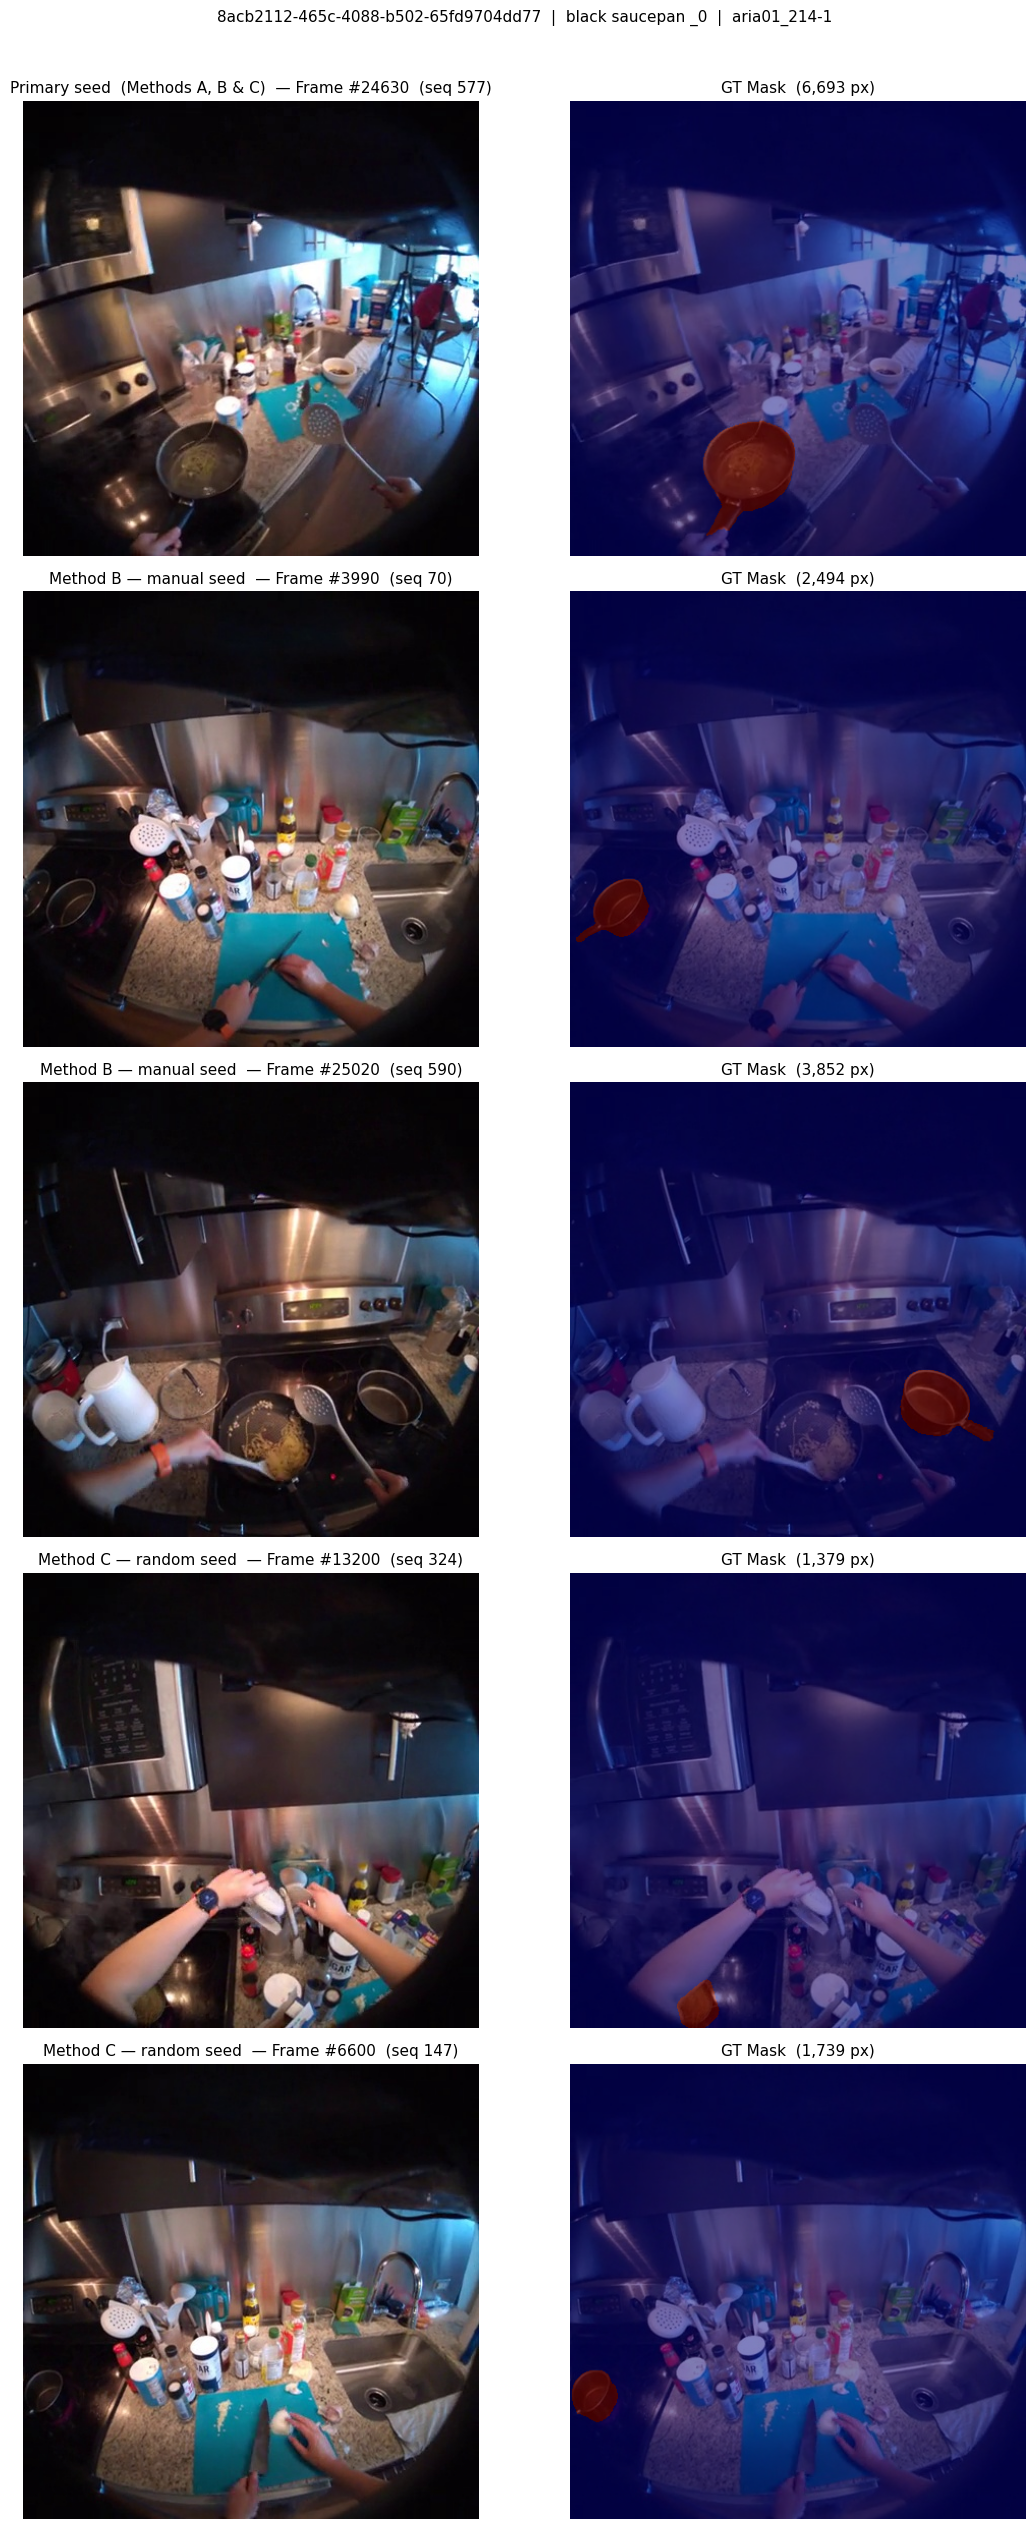

In [12]:
print(f'Loading {len(frame_nums)} frames and GT masks...')

frames_rgb = {}
gt_masks   = {}

for i, (fstr, fn) in enumerate(zip(frame_strs, frame_nums)):
    img_path = os.path.join(DATA_DIR, TAKE_UID, CAMERA, f'{fstr}.jpg')
    frames_rgb[fn] = np.array(Image.open(img_path).convert('RGB'))
    gt_masks[fn]   = decode_mask(frame_dict[fstr], H, W)
    if (i + 1) % 100 == 0 or (i + 1) == len(frame_nums):
        print(f'  loaded {i+1}/{len(frame_nums)} frames')

# ── Collect all seed frames: primary + Method B extras + Method C random ──────
_b_extra_fns = [fn for fn in METHOD_B_EXTRA_FRAME_NUMS if fn != ref_fn]                if METHOD_B_EXTRA_FRAME_NUMS is not None else []
_c_extra_fns = [fn for fn in METHOD_C_EXTRA_FRAME_NUMS if fn != ref_fn]                if METHOD_C_EXTRA_FRAME_NUMS is not None else []

# Build rows: (frame_num, label)
_seed_rows = [(ref_fn, 'Primary seed  (Methods A, B & C)')]
for fn in _b_extra_fns:
    _seed_rows.append((fn, 'Method B — manual seed'))
for fn in _c_extra_fns:
    _seed_rows.append((fn, 'Method C — random seed'))

n_rows = len(_seed_rows)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 5 * n_rows), squeeze=False)

for row, (fn, label) in enumerate(_seed_rows):
    seq_i = frame_nums.index(fn)
    gt_m  = gt_masks[fn]
    axes[row, 0].imshow(frames_rgb[fn])
    axes[row, 0].set_title(f'{label}  — Frame #{fn}  (seq {seq_i})')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(frames_rgb[fn])
    axes[row, 1].imshow(gt_m, alpha=0.5, cmap='jet')
    axes[row, 1].set_title(f'GT Mask  ({gt_m.sum():,} px)')
    axes[row, 1].axis('off')

fig.suptitle(f'{TAKE_UID}  |  {OBJECT_NAME}  |  {CAMERA}', y=1.01)
plt.tight_layout()
# _salient_path = os.path.join(RESULTS_DIR, TAKE_UID, 'seed_frames.png')
# fig.savefig(_salient_path, dpi=150, bbox_inches='tight')
# print(f'Saved salient frames → {_salient_path}')
plt.show()

## 4. Prepare Temp Video Directory

SAM 3's tracker expects a flat directory of sequentially numbered JPEGs.  
We copy the per-camera frames there in sorted order.

In [13]:
import shutil
import tempfile

tmp_video_dir = tempfile.mkdtemp(prefix='sam3_prop_cmp_')

for seq_idx, fstr in enumerate(frame_strs):
    src = os.path.join(DATA_DIR, TAKE_UID, CAMERA, f'{fstr}.jpg')
    dst = os.path.join(tmp_video_dir, f'{seq_idx:05d}.jpg')
    shutil.copy(src, dst)

print(f'Copied {len(frame_strs)} frames → {tmp_video_dir}')

mask_tensor = torch.tensor(ref_gt_mask.astype(np.float32))   # (H, W) float
n_frames    = len(frame_nums)

Copied 759 frames → /home/3152128/.tmp/sam3_prop_cmp_in37nbup


## 5. Method A — Basic SAM 3 Bi-directional Propagation

Seed the tracker with the GT mask at the reference frame, then propagate forward and backward and merge the results.

This is the baseline against which all other propagation methods are compared.

In [14]:
def collect_propagation_masks(tracker, inf_state, start_frame_idx, reverse, n_frames):
    """Run propagation and return {seq_idx: bool mask} for all yielded frames."""
    masks = {}
    for frame_idx, _, _, vrm, _ in tracker.propagate_in_video(
        inf_state,
        start_frame_idx=start_frame_idx,
        max_frame_num_to_track=n_frames,
        reverse=reverse,
        propagate_preflight=True,
    ):
        masks[frame_idx] = (vrm[0] > 0.0).cpu().numpy().squeeze()
    return masks


# ── Forward: reference → last frame ──────────────────────────────────────────
inf_state_fwd = tracker.init_state(video_path=tmp_video_dir)
tracker.add_new_mask(inference_state=inf_state_fwd, frame_idx=ref_seq_idx, obj_id=1, mask=mask_tensor)
method_a_fwd = collect_propagation_masks(tracker, inf_state_fwd, ref_seq_idx, reverse=False, n_frames=n_frames)
print(f'Forward:  {len(method_a_fwd)} frames  (seq {min(method_a_fwd)} → {max(method_a_fwd)})')

# ── Backward: reference → first frame ────────────────────────────────────────
inf_state_bwd = tracker.init_state(video_path=tmp_video_dir)
tracker.add_new_mask(inference_state=inf_state_bwd, frame_idx=ref_seq_idx, obj_id=1, mask=mask_tensor)
method_a_bwd = collect_propagation_masks(tracker, inf_state_bwd, ref_seq_idx, reverse=True, n_frames=n_frames)
print(f'Backward: {len(method_a_bwd)} frames  (seq {min(method_a_bwd)} → {max(method_a_bwd)})')

# ── Merge: backward for frames before reference, forward for the rest ─────────
method_a_masks = {
    i: (method_a_bwd if i < ref_seq_idx else method_a_fwd).get(i, empty_mask)
    for i in range(n_frames)
}
print(f'Merged:   {len(method_a_masks)} frames total')

propagate in video: 100%|██████████| 182/182 [00:06<00:00, 27.06it/s]


Forward:  182 frames  (seq 577 → 758)


propagate in video: 100%|██████████| 578/578 [00:21<00:00, 26.83it/s]

Backward: 578 frames  (seq 0 → 577)
Merged:   759 frames total


## 6. Method B — Multi-frame SAM 3 Conditioning

Seed the tracker with GT masks at **multiple reference frames** (the primary ref plus any frames
listed in `METHOD_B_EXTRA_FRAME_NUMS`), then propagate bi-directionally from the earliest seed.

All seeded frames enter `cond_frame_outputs` before propagation starts, so every intermediate
frame attends to all anchors simultaneously (up to the `max_cond_frames_in_attn=4` cap).
This tests whether flanking ground-truth anchors resolve failure cases caused by similar nearby objects.

In [15]:
if METHOD_B_EXTRA_FRAME_NUMS is None:
    print('METHOD_B_EXTRA_FRAME_NUMS is None — skipping Method B.')
    method_b_masks = {i: empty_mask for i in range(n_frames)}
    method_b_label = 'Method B (disabled)'
else:
    # Remove duplicates with the primary ref (snap_to_annotated may have aligned them)
    extra = [fn for fn in METHOD_B_EXTRA_FRAME_NUMS if fn != ref_fn]
    assert len(extra) <= 4, 'At most 4 extra frames (5 total incl. primary)'

    method_b_all_fns  = sorted({ref_fn} | set(extra))
    method_b_seq_idxs = [frame_nums.index(fn) for fn in method_b_all_fns]
    method_b_start    = method_b_seq_idxs[0]   # earliest seed — bidirectional pivot
    method_b_label    = f'Method B — {len(method_b_all_fns)}-frame conditioning'

    print(f'Seeding {len(method_b_all_fns)} reference frames: {method_b_all_fns}')
    print(f'  seq indices : {method_b_seq_idxs}')
    print(f'  pivot (fwd/bwd start) : seq {method_b_start}  frame #{method_b_all_fns[0]}')

    def seed_multi_frame_state(seq_indices):
        """Init inference state and add GT masks at each seq_idx."""
        state = tracker.init_state(video_path=tmp_video_dir)
        for si in seq_indices:
            fn_i = frame_nums[si]
            tracker.add_new_mask(
                inference_state=state,
                frame_idx=si, obj_id=1,
                mask=torch.tensor(gt_masks[fn_i].astype(np.float32)),
            )
        return state

    # ── Forward ──────────────────────────────────────────────────────────────
    inf_state_b_fwd = seed_multi_frame_state(method_b_seq_idxs)
    method_b_fwd    = collect_propagation_masks(
        tracker, inf_state_b_fwd, method_b_start, reverse=False, n_frames=n_frames
    )
    print(f'Forward:  {len(method_b_fwd)} frames  (seq {min(method_b_fwd)} → {max(method_b_fwd)})')

    # ── Backward ─────────────────────────────────────────────────────────────
    inf_state_b_bwd = seed_multi_frame_state(method_b_seq_idxs)
    method_b_bwd    = collect_propagation_masks(
        tracker, inf_state_b_bwd, method_b_start, reverse=True, n_frames=n_frames
    )
    print(f'Backward: {len(method_b_bwd)} frames  (seq {min(method_b_bwd)} → {max(method_b_bwd)})')

    # ── Merge ─────────────────────────────────────────────────────────────────
    method_b_masks = {
        i: (method_b_bwd if i < method_b_start else method_b_fwd).get(i, empty_mask)
        for i in range(n_frames)
    }
    print(f'Merged:   {len(method_b_masks)} frames total')

Seeding 3 reference frames: [3990, 24630, 25020]
  seq indices : [70, 577, 590]
  pivot (fwd/bwd start) : seq 70  frame #3990


propagate in video: 100%|██████████| 689/689 [00:26<00:00, 25.99it/s]


Forward:  689 frames  (seq 70 → 758)


propagate in video: 100%|██████████| 71/71 [00:02<00:00, 26.17it/s]

Backward: 71 frames  (seq 0 → 70)
Merged:   759 frames total


## 7. Method C — Random Multi-frame Conditioning

Same SAM 3 multi-frame conditioning as Method B, but the extra reference frames are
**randomly sampled** from the annotated set rather than manually chosen.

The number of seed frames is identical to Method B, so any IoU difference is attributable
purely to **frame selection quality** (manual vs random), not to the number of anchors.

In [ ]:
if METHOD_C_EXTRA_FRAME_NUMS is None:
    print('METHOD_C_EXTRA_FRAME_NUMS is None — skipping Method C.')
    method_c_masks = {i: empty_mask for i in range(n_frames)}
    method_c_label = 'Method C (disabled)'
else:
    extra_c = [fn for fn in METHOD_C_EXTRA_FRAME_NUMS if fn != ref_fn]

    method_c_all_fns  = sorted(set(extra_c))
    method_c_seq_idxs = [frame_nums.index(fn) for fn in method_c_all_fns]
    method_c_start    = method_c_seq_idxs[0]
    method_c_label    = f'Method C — {len(method_c_all_fns)}-frame random conditioning'

    print(f'Seeding {len(method_c_all_fns)} random reference frames: {method_c_all_fns}')
    print(f'  seq indices : {method_c_seq_idxs}')
    print(f'  pivot (fwd/bwd start) : seq {method_c_start}  frame #{method_c_all_fns[0]}')

    # ── Forward ──────────────────────────────────────────────────────────────
    inf_state_c_fwd = seed_multi_frame_state(method_c_seq_idxs)
    method_c_fwd    = collect_propagation_masks(
        tracker, inf_state_c_fwd, method_c_start, reverse=False, n_frames=n_frames
    )
    print(f'Forward:  {len(method_c_fwd)} frames  (seq {min(method_c_fwd)} → {max(method_c_fwd)})')

    # ── Backward ─────────────────────────────────────────────────────────────
    inf_state_c_bwd = seed_multi_frame_state(method_c_seq_idxs)
    method_c_bwd    = collect_propagation_masks(
        tracker, inf_state_c_bwd, method_c_start, reverse=True, n_frames=n_frames
    )
    print(f'Backward: {len(method_c_bwd)} frames  (seq {min(method_c_bwd)} → {max(method_c_bwd)})')

    # ── Merge ─────────────────────────────────────────────────────────────────
    method_c_masks = {
        i: (method_c_bwd if i < method_c_start else method_c_fwd).get(i, empty_mask)
        for i in range(n_frames)
    }
    print(f'Merged:   {len(method_c_masks)} frames total')

Seeding 3 random reference frames: [3930, 7770, 19860]
  seq indices : [68, 186, 472]
  pivot (fwd/bwd start) : seq 68  frame #3930


propagate in video:   4%|▍         | 28/691 [00:01<00:25, 26.22it/s]

## 8. IoU Comparison

In [ ]:
# ── Register all methods to evaluate ─────────────────────────────────────────
METHODS = [
    ('Method A — Single-frame (baseline)',   method_a_masks),
    (method_b_label,                         method_b_masks),
    (method_c_label,                         method_c_masks),
]

# ── Compute per-frame IoU for every method ────────────────────────────────────
iou_per_method = {}
mean_iou       = {}

for label, pred_masks in METHODS:
    per_frame = {}
    for seq_idx, fn in enumerate(frame_nums):
        per_frame[fn] = compute_iou(pred_masks[seq_idx], gt_masks[fn])
    iou_per_method[label] = per_frame
    mean_iou[label]       = float(np.mean(list(per_frame.values())))

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'{"Method":<50}  {"Mean IoU":>9}  {"IoU>0.5":>8}  {"IoU>0.75":>9}')
print('-' * 84)
for label, _ in METHODS:
    vals = list(iou_per_method[label].values())
    n    = len(vals)
    gt50 = sum(v > 0.5  for v in vals) / n * 100
    gt75 = sum(v > 0.75 for v in vals) / n * 100
    print(f'{label:<50}  {mean_iou[label]:>9.4f}  {gt50:>7.1f}%  {gt75:>8.1f}%')

# ── Save per-frame IoU as CSV ─────────────────────────────────────────────────
import csv
_csv_path = os.path.join(RESULTS_DIR, 'iou_per_frame.csv')
with open(_csv_path, 'w', newline='') as _f:
    _w = csv.writer(_f)
    _w.writerow(['frame_num'] + [label for label, _ in METHODS])
    for fn in frame_nums:
        _w.writerow([fn] + [f'{iou_per_method[label][fn]:.6f}' for label, _ in METHODS])
print(f'Saved IoU CSV → {_csv_path}')

In [ ]:
PALETTE = ['steelblue', 'tomato', 'seagreen', 'darkorchid', 'darkorange']
STYLES  = ['-', '-', '-', '-', (0, (3, 1, 1, 1))]

fig, ax = plt.subplots(figsize=(14, 4))

for (label, _), colour, style in zip(METHODS, PALETTE, STYLES):
    ax.plot(
        frame_nums,
        [iou_per_method[label][fn] for fn in frame_nums],
        label=f'{label}  (mean IoU = {mean_iou[label]:.3f})',
        color=colour, linestyle=style, linewidth=1.5, alpha=0.85,
    )

# Primary seed (shared by all methods)
ax.axvline(ref_fn, color='steelblue', linestyle='--', linewidth=1.4,
           label=f'Primary seed  (frame #{ref_fn})')

# Method B manual seed frames
if METHOD_B_EXTRA_FRAME_NUMS is not None:
    for _i, _fn in enumerate(fn for fn in method_b_all_fns if fn != ref_fn):
        ax.axvline(_fn, color='tomato', linestyle='--', linewidth=1.0,
                   label='Method B manual seeds' if _i == 0 else None)

# Method C random seed frames
if METHOD_C_EXTRA_FRAME_NUMS is not None:
    for _i, _fn in enumerate(fn for fn in method_c_all_fns if fn != ref_fn):
        ax.axvline(_fn, color='seagreen', linestyle='--', linewidth=1.0,
                   label='Method C random seeds' if _i == 0 else None)

ax.set_xlabel('Frame number')
ax.set_ylabel('IoU')
ax.set_ylim(0, 1.05)
ax.set_title(f'Per-frame IoU — "{OBJECT_NAME}"  |  camera: {CAMERA}')
ax.legend(fontsize=9)
plt.tight_layout()
_iou_plot_path = os.path.join(RESULTS_DIR, 'iou_curve.png')
fig.savefig(_iou_plot_path, dpi=150, bbox_inches='tight')
print(f'Saved IoU curve → {_iou_plot_path}')
plt.show()

## 9. Visualisation — Side-by-side Overlays

Predicted mask = **red** · GT mask = **green** · Overlap = **yellow**  
Frames are shown every `VIS_STRIDE` annotated frame step(s).

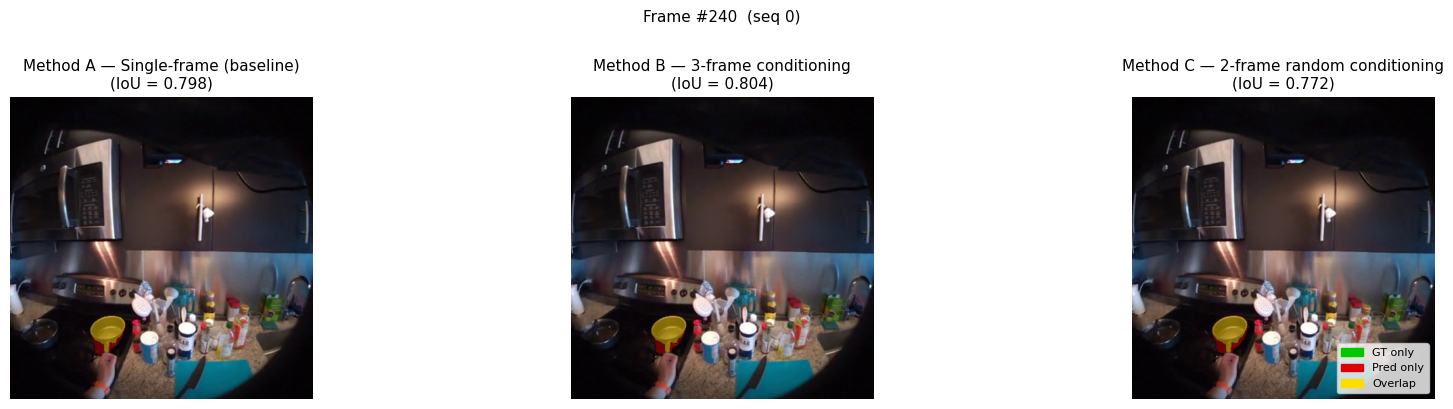

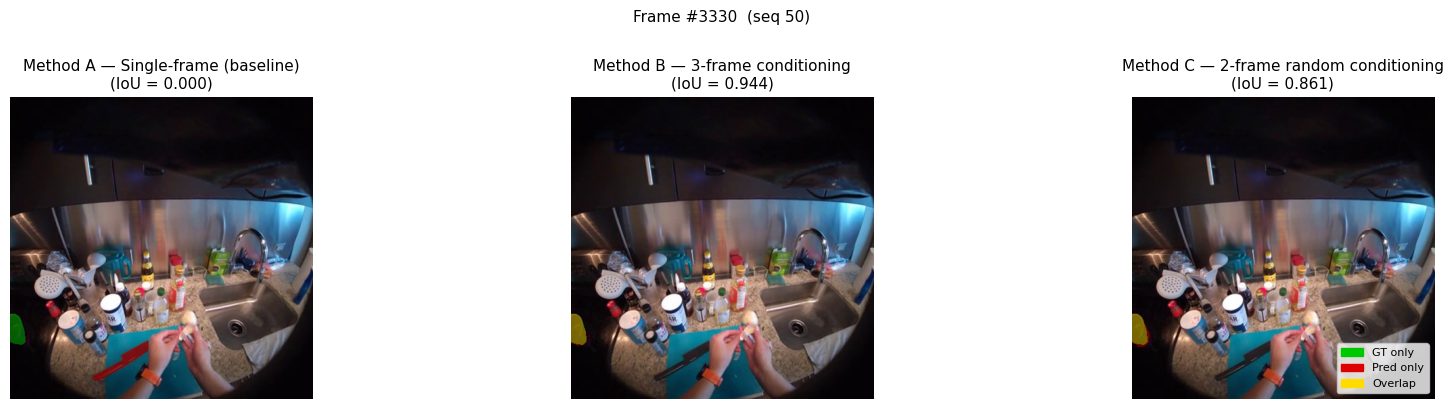

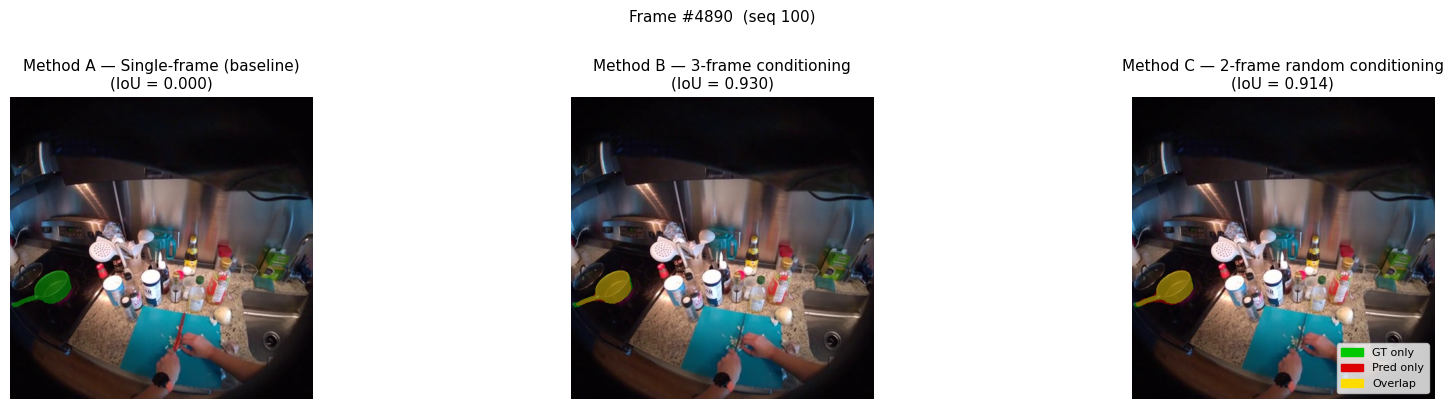

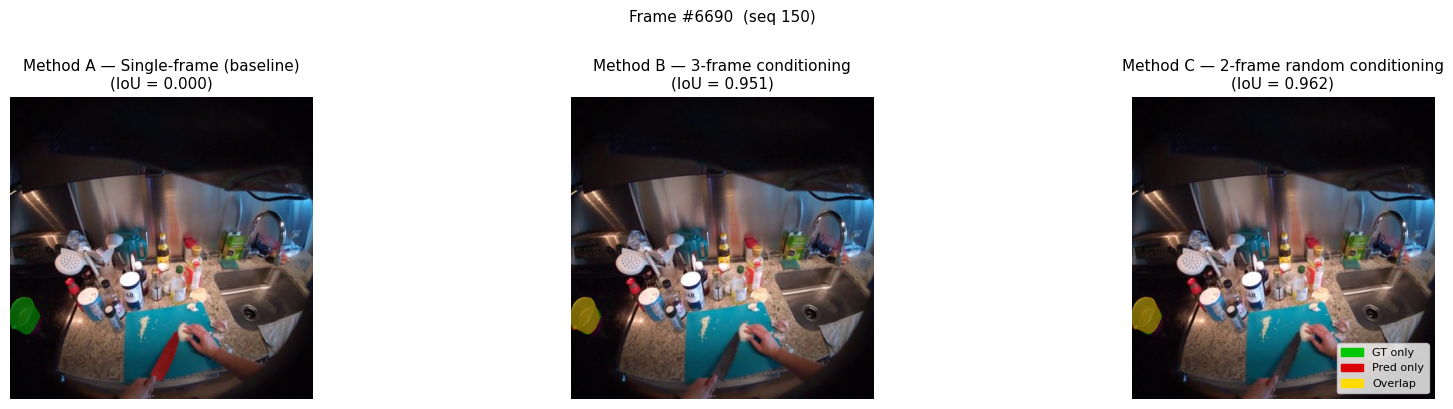

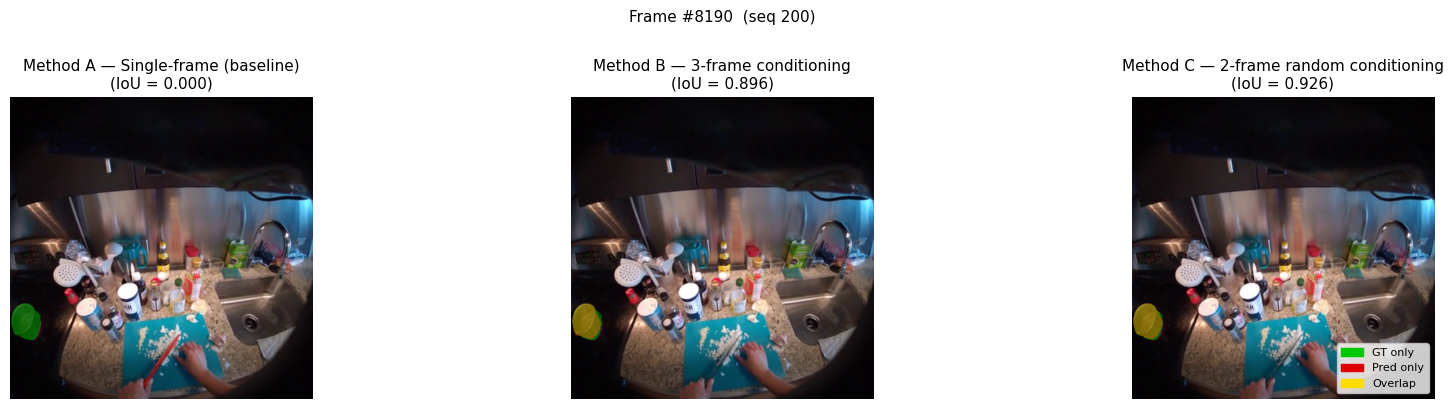

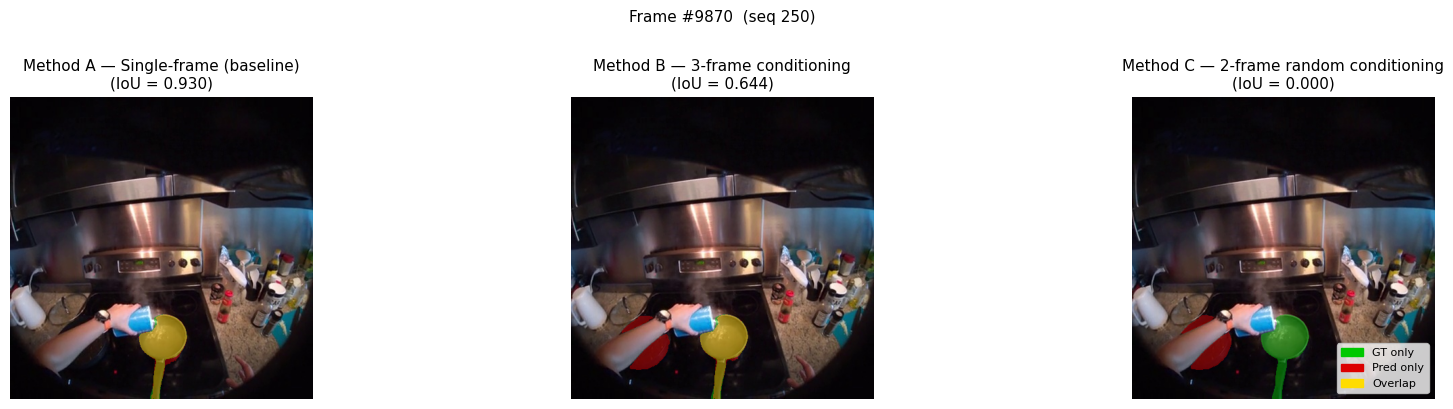

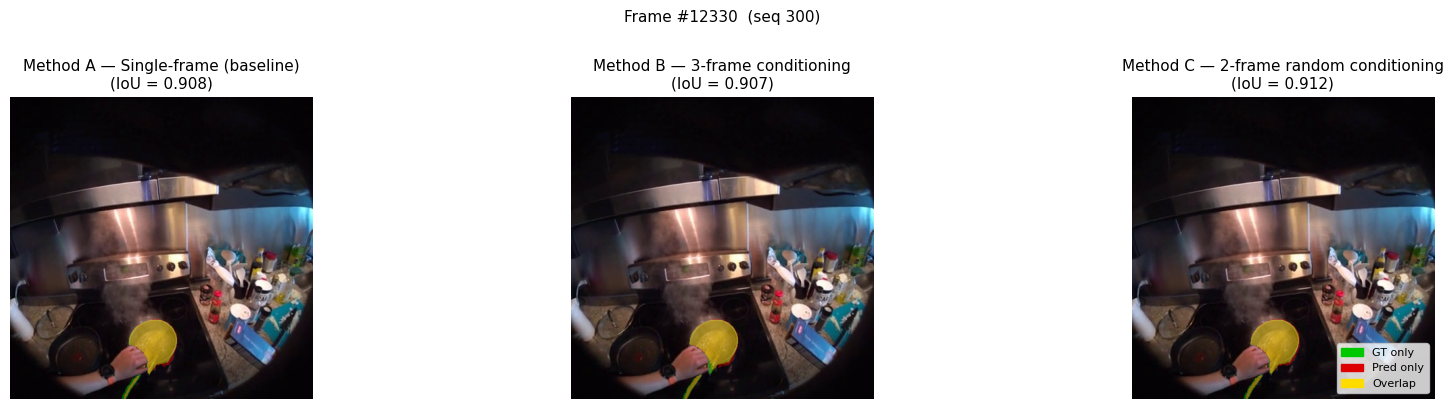

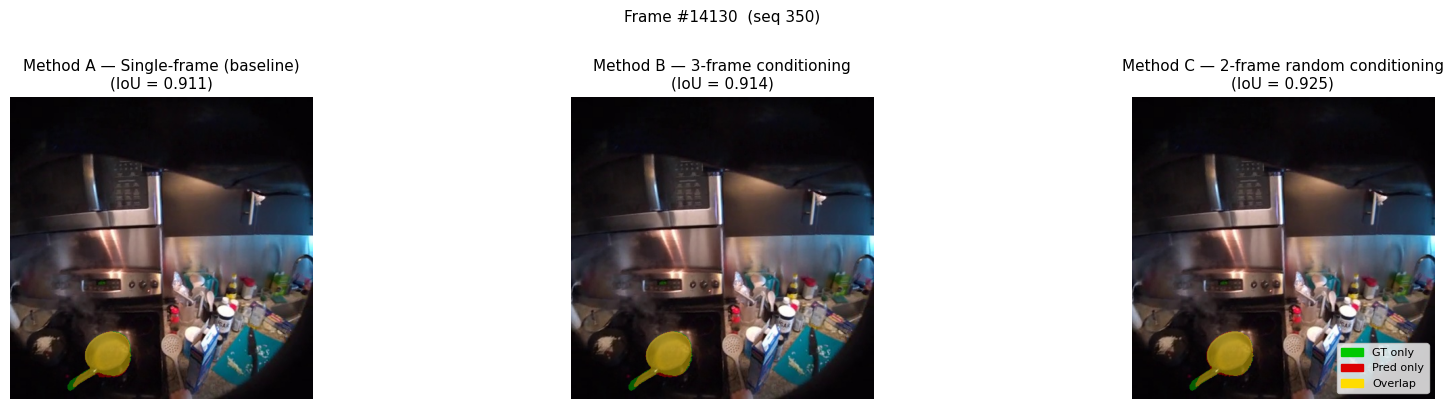

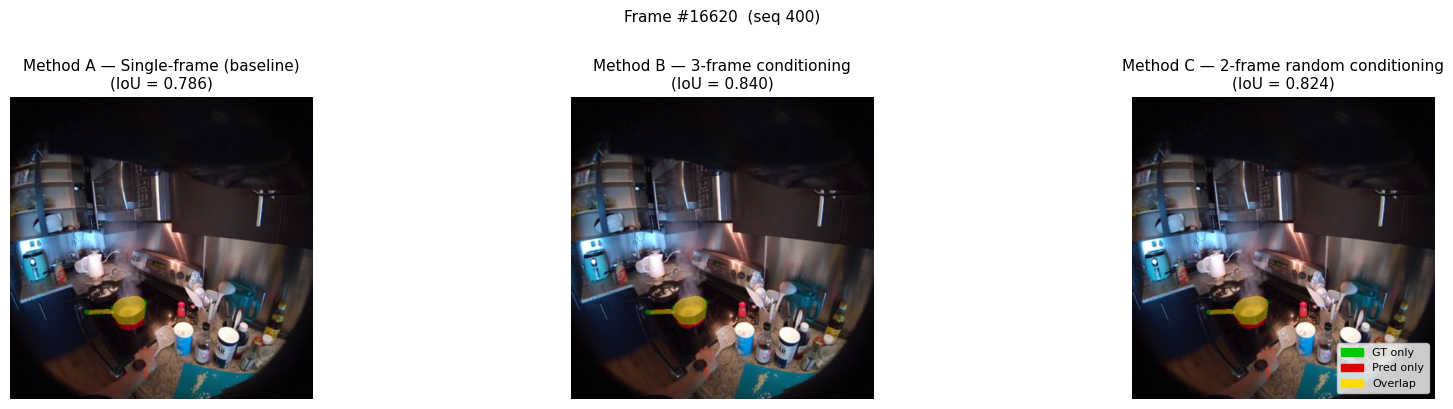

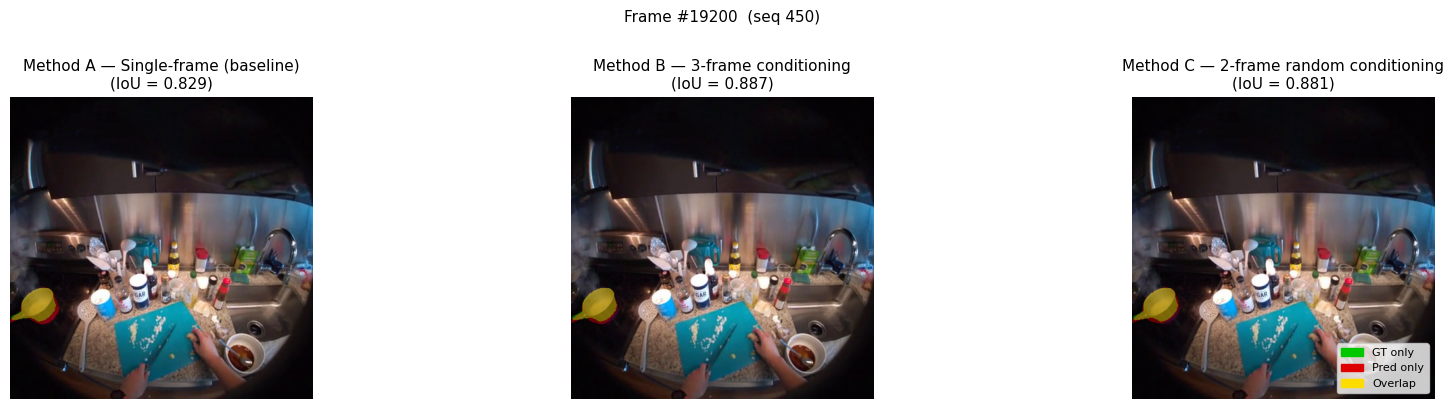

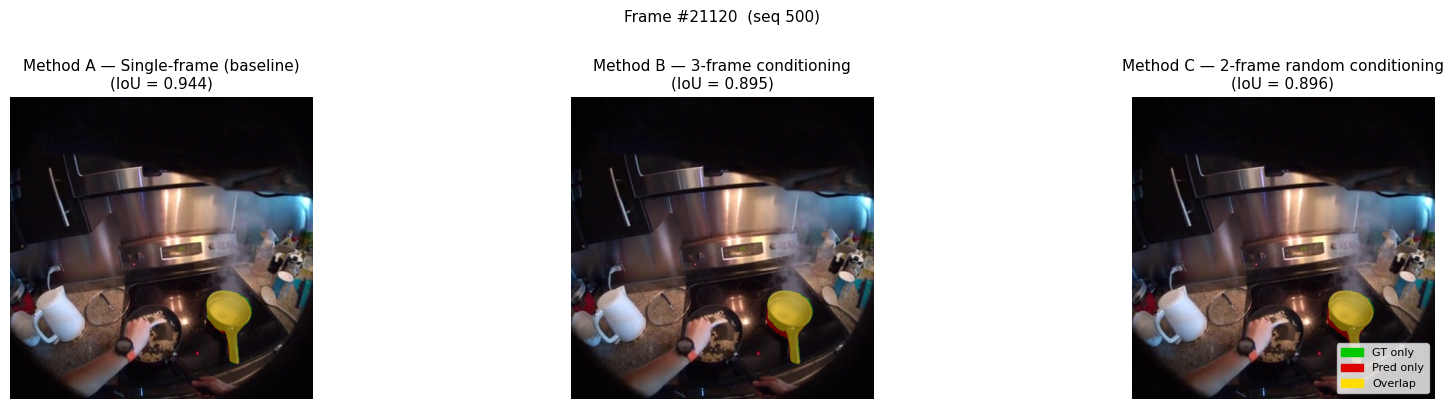

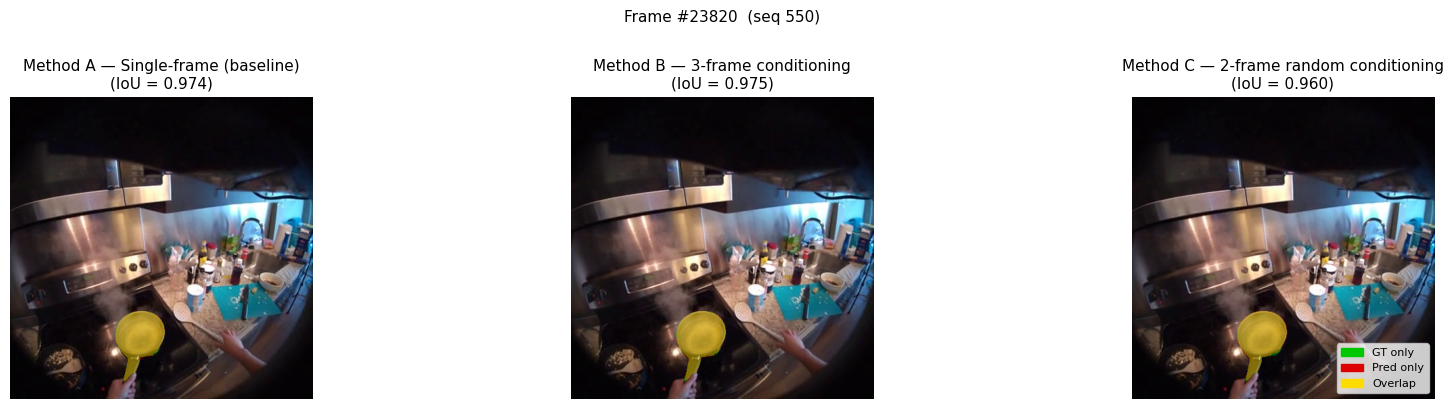

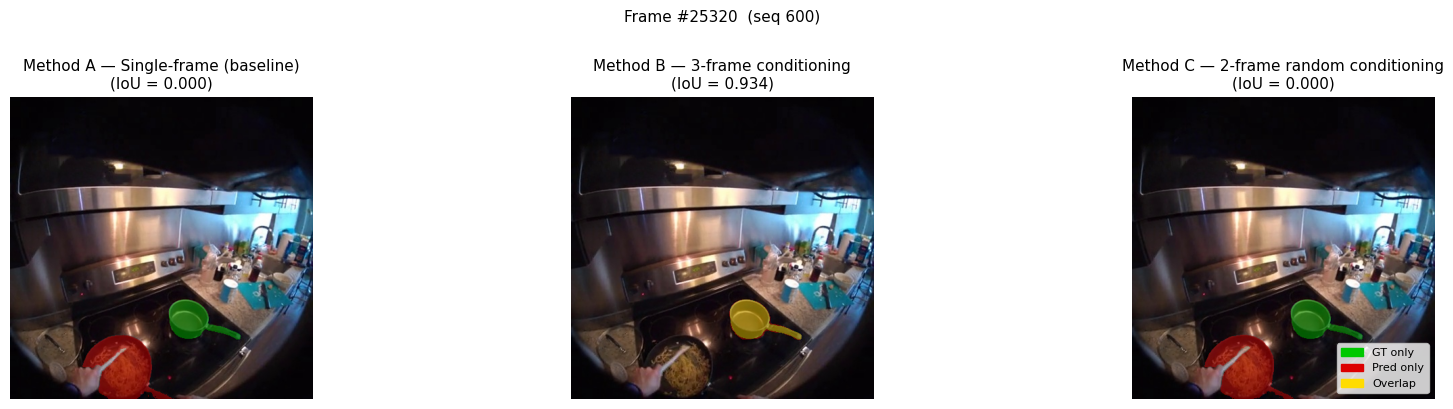

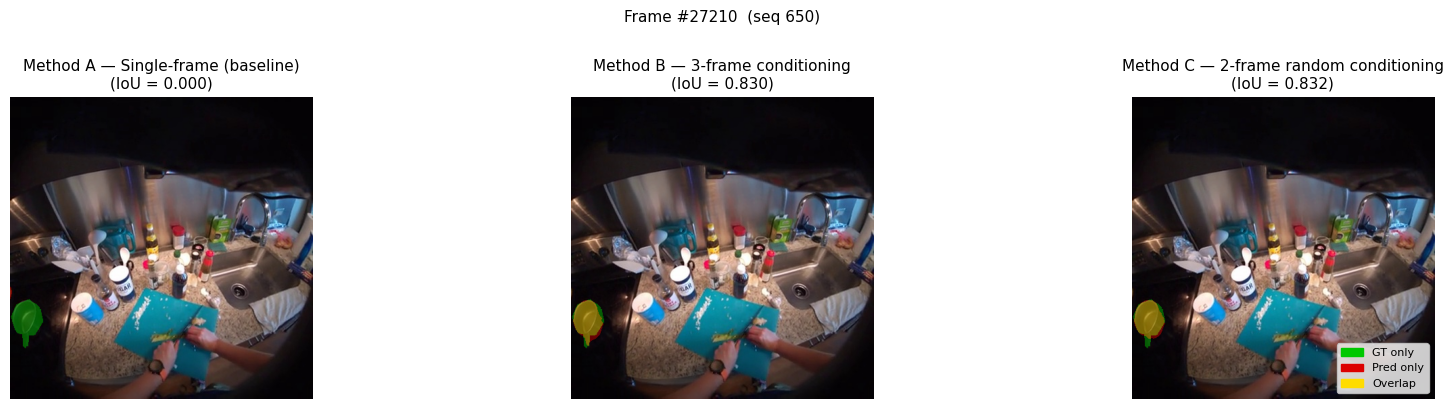

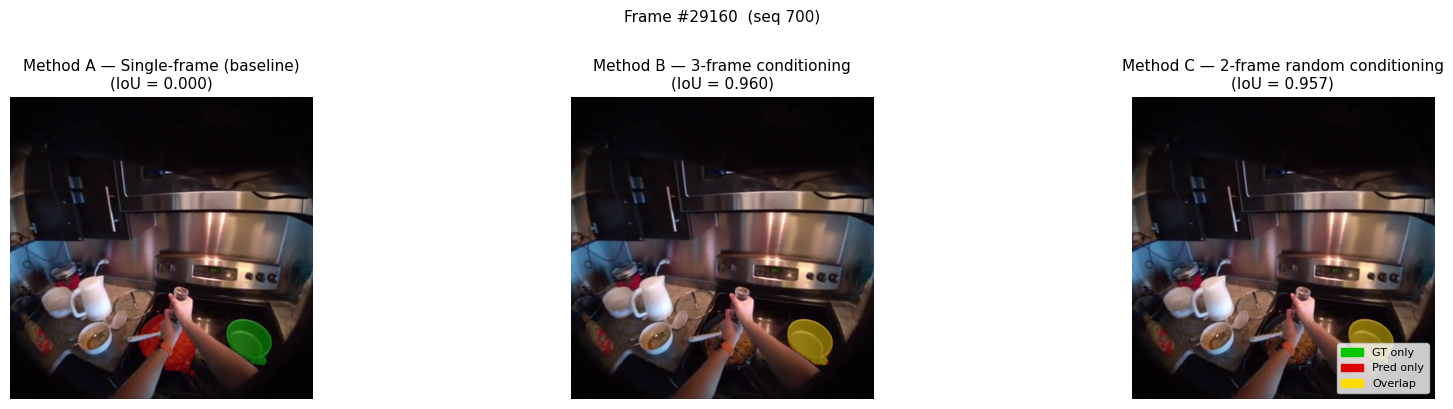

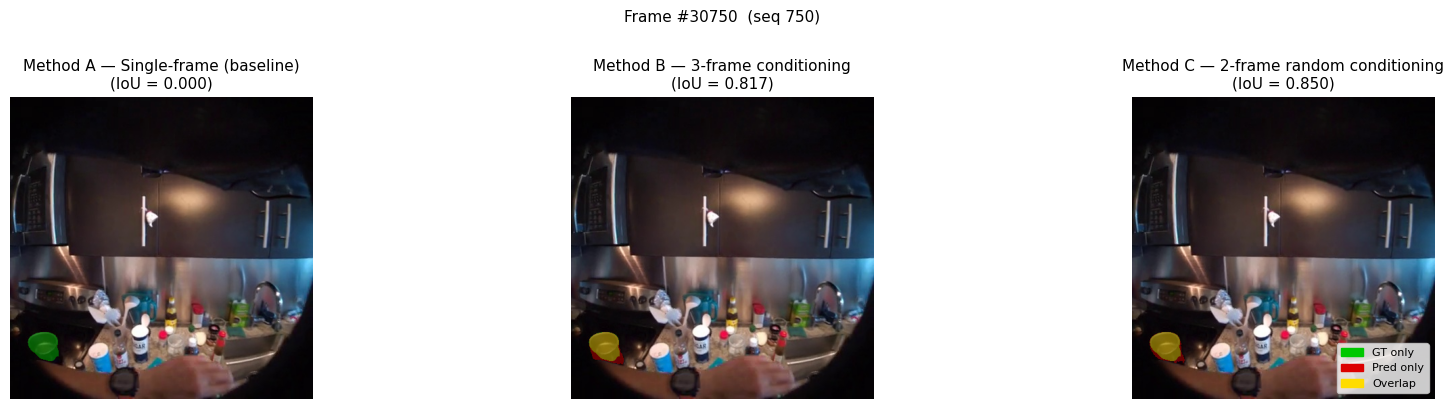

FileNotFoundError: [Errno 2] No such file or directory: '../data/test_mask_prop/propagation_results/sidebyside/frame_0000240.png'

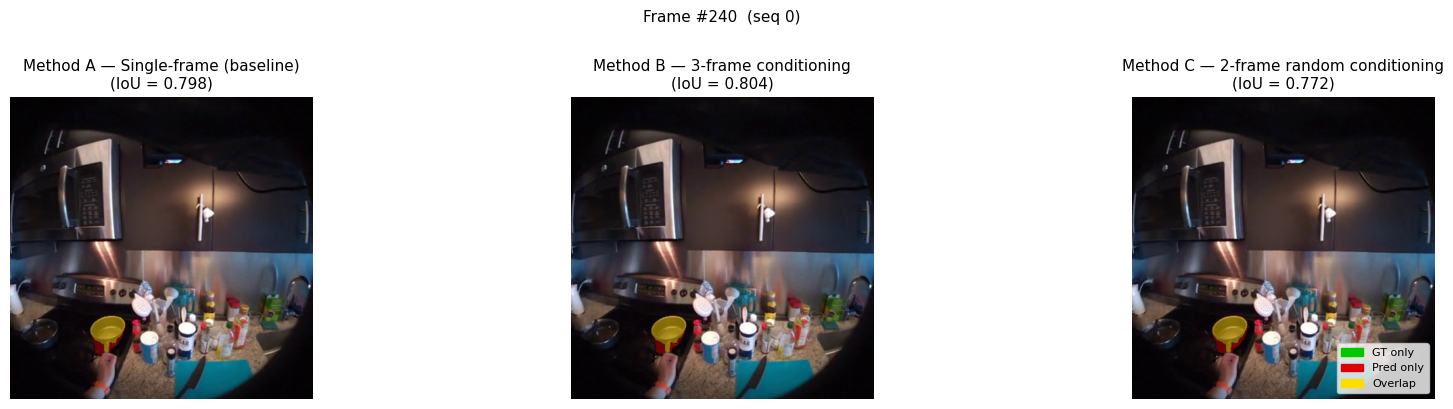

In [19]:
_b_seed_fns = set(method_b_all_fns) if METHOD_B_EXTRA_FRAME_NUMS is not None else set()
_c_seed_fns = set(method_c_all_fns) if METHOD_C_EXTRA_FRAME_NUMS is not None else set()
_seed_fns   = {ref_fn} | _b_seed_fns | _c_seed_fns

# ── Inline display (VIS_STRIDE) ───────────────────────────────────────────────
for seq_idx in range(0, len(frame_nums), VIS_STRIDE):
    fn = frame_nums[seq_idx]
    plot_methods(
        seq_idx=seq_idx,
        frame_num=fn,
        method_results=[
            (label, pred_masks[seq_idx], iou_per_method[label][fn])
            for label, pred_masks in METHODS
        ],
        gt=gt_masks[fn],
        rgb=frames_rgb[fn],
        seed_frame_nums=_seed_fns,
    )

# ── Save to disk (SAVE_STRIDE) ────────────────────────────────────────────────
_saved = 0
for seq_idx in range(0, len(frame_nums), SAVE_STRIDE):
    fn  = frame_nums[seq_idx]
    gt  = gt_masks[fn]
    rgb = frames_rgb[fn]

    n   = len(METHODS)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (label, pred_masks) in zip(axes, METHODS):
        iou = iou_per_method[label][fn]
        ax.imshow(render_overlay(rgb, pred_masks[seq_idx], gt))
        ax.set_title(f'{label}\n(IoU = {iou:.3f})')
        ax.axis('off')
    axes[-1].legend(
        handles=[
            mpatches.Patch(color=(0, 200/255, 0),   label='GT only'),
            mpatches.Patch(color=(220/255, 0, 0),    label='Pred only'),
            mpatches.Patch(color=(1.0, 220/255, 0),  label='Overlap'),
        ],
        loc='lower right', fontsize=8,
    )
    markers = []
    if fn == ref_fn:                         markers.append('primary seed')
    if fn in _b_seed_fns and fn != ref_fn:   markers.append('Method B seed')
    if fn in _c_seed_fns and fn != ref_fn:   markers.append('Method C seed')
    tag = f'  ← {", ".join(markers)}' if markers else ''
    fig.suptitle(f'Frame #{fn}  (seq {seq_idx}){tag}', y=1.01)
    plt.tight_layout()
    _out = os.path.join(RESULTS_DIR, 'sidebyside', f'frame_{fn:07d}.png')
    fig.savefig(_out, dpi=120, bbox_inches='tight')
    plt.close(fig)
    _saved += 1

print(f'Saved {_saved} side-by-side frames → {os.path.join(RESULTS_DIR, "sidebyside/")}')


## 10. Clean-up

Remove the temporary video directory and free GPU resources.

In [ ]:
shutil.rmtree(tmp_video_dir, ignore_errors=True)
print(f'Removed {tmp_video_dir}')

for _state in ['inf_state_fwd', 'inf_state_bwd', 'inf_state_b_fwd', 'inf_state_b_bwd']:
    if _state in dir():
        del globals()[_state]
import gc
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()
print('Done.')